# D - Create PRESS from predicted CRS 

In [1]:
import sys
import os

# Add the project root directory to sys.path so that the src package can be imported 
project_root = os.path.abspath("../../")  # Adjust the relative path as needed
if project_root not in sys.path:
    sys.path.append(project_root)

In [2]:
import pandas as pd

# Load the predicted CRS data from feather file
crs = pd.read_feather("../../data/output/crs_predicted.feather")

In [3]:
# Filter CRS for projects with probability_is_statistics >= 0.999409 (chosen after manual inspection of text_mining_descriptions in range [0.99, 1])
press = crs[crs['probability_is_statistics'] >= 0.999409].copy()

# Make gen_all filter as probability_is_gender >= 0.991 (chosen after manual inspection of text_mining_descriptions in range [0.95, 1])
press['gen_all'] = press['probability_is_gender'] >= 0.991

In [4]:
# Remove gen_donor column, as there are no projects from those two agencies and would just confuse
press.drop(columns=['gen_donor'], inplace=True)

#### Remove projects after manual inspection of top funding projects 

In [5]:
# Load descriptions to remove after review 
descriptions_to_remove = pd.read_excel("../../data/auxiliary/text_descriptions_to_remove_after_review.xlsx")

# Strip whitespaces from the 'text_mining_description' column in descriptions_to_remove
descriptions_to_remove['text_mining_description'] = descriptions_to_remove['text_mining_description'].str.strip()

In [6]:
import numpy as np

# Exclude rows where project_title contains 'international accountability' and 'national account' is in stat_keywords
press = press[~(
    press['project_title'].str.lower().str.contains('national accountability', na=False) &
    press['stat_keywords'].apply(
        lambda x: any(kw == 'national account' for kw in x) if isinstance(x, (list, np.ndarray)) else False
    )
)]

import re

# Combine all strings in descriptions_to_remove into a single regex pattern
pattern = '|'.join(map(re.escape, descriptions_to_remove['text_mining_description']))

# Remove rows where text_mining_description contains any of the strings in descriptions_to_remove
press = press[~press['text_mining_description'].str.contains(pattern, case=False, na=False)]

# Revmove all text_mining_description which start with "CAMP EXPENSES" (false Saudi Arabia funding containing "information system"), separate treatment to avoid excluding all projects conatining "CAMP EXPENSES", but only the projects that start with it
press = press[~press['text_mining_description'].str.startswith("CAMP EXPENSES", na=False)]

#### Remove projects using certain financial instruments

In [7]:
# For finance_t, exclude all values except for 110, 421, and 520
press = press[press['finance_t'].isin([110, 421, 520])]

# For flow_code, exclude 60 (private sector instruments)
press = press[press['flow_code'] != 60]

# For category, exclude 60 (private sector instruments)
press = press[press['category'] != 60]

#### Add topic focus 

Topic focus as search of topic focus keywords in combination of project title, short description, long description.

Currently this has been implemented hard-coded for AI, but can later be generalized to other topic foci through the use of keywords in the topic focus xlsx.

In [8]:
from src.text_processing import normalize_str, detect_language, lemmatize_batch, detect_keywords, detect_acronyms, process_keywords

In [9]:
import pandas as pd
# Load keywords from Excel file
keywords_file_path = "../../data/keywords/topic_focus/keywords_topic_focus.xlsx"
AI_keywords = pd.read_excel(keywords_file_path, sheet_name="AI")
AI_acronyms = pd.read_excel(keywords_file_path, sheet_name="AI acronyms")

# Drop id column for all keywords with loop
for df in [AI_keywords, AI_acronyms]:
    if 'id' in df.columns:
        df.drop(columns=['id'], inplace=True)
    
    print(f"{df.columns.tolist()}")

# Process keywords
AI_keywords = process_keywords(AI_keywords, remove_stopwords=True)

# Lowercase all strings in the acronyms dataframes
AI_acronyms = AI_acronyms.map(lambda x: x.lower() if isinstance(x, str) else x)

['en', 'fr', 'es', 'de']
['en', 'fr', 'es', 'de']


In [10]:
print(press["project_title"].isna().sum())
print(press["text_mining_description"].isna().sum())

2310
183


In [11]:
press[
    press["project_title"].isna()
    | press["text_mining_description"].isna()
][["project_title", "text_mining_description"]].head()

,project_title,text_mining_description
130,NaN,VARIOUS SURVEYS: N/A
531,NaN,AIRPORT SURVEY: N/A
533,NaN,AIRPORT SURVEY: N/A
1541,NaN,METEOROLOGICAL STATI: N/A
1600,NaN,HARBOUR SURVEY: N/A


In [12]:
# Make topic_focus_description as project_title + ": " + text_mining_description (= project_title: short description: long description)
press['topic_focus_description'] = press['project_title'].astype(str) + ": " + press['text_mining_description'].astype(str)

# Detect language and normalize
press["lang_topic_focus_description"] = press['topic_focus_description'].apply(detect_language)
press['normalized_topic_focus_description'] = press['topic_focus_description'].apply(normalize_str)

In [13]:
for lang in press['lang_topic_focus_description'].unique():
    # Filter the DataFrame for the current language
    lang_df = press[press['lang_topic_focus_description'] == lang]

    if 'lemmatized_topic_focus_description' not in press.columns:
        press['lemmatized_topic_focus_description'] = None  # Initialize the column if it doesn't exist
    press['lemmatized_topic_focus_description'] = press['lemmatized_topic_focus_description'].astype(object)
    
    # Process the batch and update the original DataFrame
    press.loc[lang_df.index, 'lemmatized_topic_focus_description'] = lemmatize_batch(lang_df['normalized_topic_focus_description'].tolist(), lang, batch_size=1000, remove_stopwords=True)

    # Lowercase lemmatized titles in case spacy lemmatizes to uppercase
    press['lemmatized_topic_focus_description'] = press['lemmatized_topic_focus_description'].str.lower()

In [14]:
# Detect keywords in the lemmatized topic focus description
press['AI_keywords'] = press.apply(lambda row: detect_keywords(row['lemmatized_topic_focus_description'], row['lang_topic_focus_description'], AI_keywords), axis=1)

# Detect acronyms in the normalized topic focus description
press['AI_acronyms'] = press.apply(lambda row: detect_acronyms(row['normalized_topic_focus_description'], row['lang_topic_focus_description'], AI_acronyms), axis=1)

In [15]:
# Make AI_focus as True if AI_keywords is not null or AI_acronyms is not null
press['AI_focus'] = (
    (press['AI_keywords'].notna()) |    # AI_keywords is not null
    (press['AI_acronyms'].notna())      # AI_acronyms is not null
)

# If lang_topic_focus_description == "it" and AI_acronyms contains " ai ", set AI_focus to False
press.loc[
    (press['lang_topic_focus_description'] == 'it') & 
    (crs['stat_acronyms'].apply(lambda x: isinstance(x, (list, np.ndarray)) and ' ai ' in x)),
    'AI_focus'
] = False

# Remove topic_focus_description, normalized_topic_focus_description, lemmatized_topic_focus_description columns
press.drop(columns=['lang_topic_focus_description', 'topic_focus_description', 'normalized_topic_focus_description', 'lemmatized_topic_focus_description'], inplace=True)

#### Add RegionName as in PRESS 2024

This information might be irrelevant in the future as it used to be used for Clearinghouse

In [16]:
# Load PRESS 2024
press_2024 = pd.read_excel("../../data/auxiliary/PRESS_2024.xlsx")      

# Get RegionName and dac_regionname from press_2024
region_mapping = press_2024[['RegionName', 'recipientcode']].drop_duplicates(keep='first')
region_mapping_for_missing = press_2024[['RegionName', 'dac_regionname']].drop_duplicates(keep='first')

# Rename dac_regionname to regionname
region_mapping_for_missing.rename(columns={'dac_regionname': 'region_name'}, inplace=True)

# Remove row with RegionName == 'Eastern Europe' and regionname == 'South & Central Asia'
region_mapping_for_missing = region_mapping_for_missing[
    (region_mapping_for_missing['RegionName'] != 'Eastern Europe') & 
    (region_mapping_for_missing['region_name'] != 'South & Central Asia')
]

# Rename recipientcode to recipient_code
region_mapping.rename(columns={'recipientcode': 'recipient_code'}, inplace=True)

# Left join region_mapping to press on region_name
press = pd.merge(press, region_mapping, on='recipient_code', how='left', validate='m:1')

# If RegionName is missing, use the regionname from region_mapping_for_missing by merging base on region_name
press = pd.merge(press, region_mapping_for_missing, on='region_name', how='left', suffixes=('', '_missing'))

# Replace missing RegionName with region_name_missing
press['RegionName'] = press['RegionName'].fillna(press['RegionName_missing'])

# Drop region_name_missing column
press.drop(columns=['RegionName_missing'], inplace=True)

# Rename region_name to dac_regionname
press.rename(columns={'region_name': 'dac_regionname'}, inplace=True)

# Replace missing RegionName with region_name_missing
press['RegionName'] = press['RegionName'].fillna(press['dac_regionname'])

#### Add ReporteName as in PRESS 2024

This information might be irrelevant in the future as it used to be used for Clearinghouse, but in 2025 data processing for Clearinghouse aligned so that donor_name is used in on CH instead of ReporterName

In [17]:
# Get ReporterName and donorname from press_2024
reporter_mapping = press_2024[['ReporterName', 'donorname']].drop_duplicates(keep='first')

# Rename donorname to donor_name
reporter_mapping.rename(columns={'donorname': 'donor_name'}, inplace=True)

# Left join reporter_mapping to press on donorname
press = pd.merge(press, reporter_mapping, on='donor_name', how='left', validate='m:1')

# If ReporterName is NaN (no projects previously), set it to donor_name
press['ReporterName'] = press['ReporterName'].fillna(press['donor_name'])

#### Add DonorType (DAC, non-DAC, multilateral, private)

In [18]:
# DAC donor types 
donor_categories = pd.read_excel("../../data/auxiliary/donor_categories.xlsx")

# Remove Data Explorer code and DonorNameE from donor_categories
donor_categories = donor_categories[['DonorCode', 'DonorType']]

# Rename DonorCode to donor_code
donor_categories.rename(columns={'DonorCode': 'donor_code'}, inplace=True)

# Left join donor_categories to press on donor_code
press = pd.merge(press, donor_categories, on='donor_code', how='left', validate='m:1')

# Rename DonorType to donor_type
press.rename(columns={'DonorType': 'donor_type'}, inplace=True)

#### Add Recipient ISO codes & SIDS classfication as of 2024 (from CRS codebook)

In [19]:
# Read ISO codes from 'Recipient' sheet 
iso_codes = pd.read_excel("../../data/auxiliary/DAC-CRS-CODES.xlsx", sheet_name="Recipient")

# Add ISO codes 
iso_codes = iso_codes[['Recipient code', 'ISOcode', 'SIDS']]

# Drop rows with recipient_code >= 889
iso_codes = iso_codes[iso_codes['Recipient code'] < 889]

# Rename Recipient Code to recipient_code, ISOcode to iso 
iso_codes.rename(columns={'Recipient code': 'recipient_code', 'ISOcode': 'recipient_iso'}, inplace=True)

# Left join iso_codes to press on recipient_code
press = pd.merge(press, iso_codes, on='recipient_code', how='left', validate='m:1')

# Set SIDS to True if SIDS 1, False if 0 with as.type(bool)
# press['SIDS'] = (press['SIDS'] == 1).astype(bool)
press['SIDS'] = (press['SIDS'] == 1).astype('boolean')

# If recipient_iso is NA, set SIDS to NA
press.loc[press['recipient_iso'].isna(), 'SIDS'] = pd.NA

In [20]:
# Manually correct recipient_iso codes for some countries that are in the CRS but not in the ISO code list
country_iso_data = [
    {'recipient_name': 'Saudi Arabia', 'recipient_iso': 'SAU'},
    {'recipient_name': 'Croatia', 'recipient_iso': 'HRV'},
    {'recipient_name': 'Anguilla', 'recipient_iso': 'AIA'},
    {'recipient_name': 'Barbados', 'recipient_iso': 'BRB'},
    {'recipient_name': 'Antigua and Barbuda', 'recipient_iso': 'ATG'},
    {'recipient_name': 'Chile', 'recipient_iso': 'CHL'},
    {'recipient_name': 'Cyprus', 'recipient_iso': 'CYP'},
    {'recipient_name': 'Malta', 'recipient_iso': 'MLT'},
    {'recipient_name': 'East African Community', 'recipient_iso': None},
    {'recipient_name': 'Seychelles', 'recipient_iso': 'SYC'},
    {'recipient_name': 'Netherlands Antilles', 'recipient_iso': 'ANT'},
    {'recipient_name': 'Aruba', 'recipient_iso': 'ABW'},
    {'recipient_name': 'States Ex-Yugoslavia unspecified', 'recipient_iso': None},
    {'recipient_name': 'Uruguay', 'recipient_iso': 'URY'},
    {'recipient_name': 'Turks and Caicos Islands', 'recipient_iso': 'TCA'},
    {'recipient_name': 'Gibraltar', 'recipient_iso': 'GIB'},
    {'recipient_name': 'Korea', 'recipient_iso': 'KOR'},
    {'recipient_name': 'Slovenia', 'recipient_iso': 'SVN'},
    {'recipient_name': 'Trinidad and Tobago', 'recipient_iso': 'TTO'},
    {'recipient_name': 'Oman', 'recipient_iso': 'OMN'},
    {'recipient_name': 'Cook Islands', 'recipient_iso': 'COK'},
    {'recipient_name': 'Mayotte', 'recipient_iso': 'MYT'},
    {'recipient_name': 'Saint Kitts and Nevis', 'recipient_iso': 'KNA'}
]

country_iso_df = pd.DataFrame(country_iso_data)

# Replace missing recipient_iso in press with country_iso_df
for index, row in country_iso_df.iterrows():
    press.loc[press['recipient_name'] == row['recipient_name'], 'recipient_iso'] = row['recipient_iso']

# Change SIDS status for some countries with manually corrected ISO codes: BRB, ATG, AIA, SYC, ABW, TCA, TTO, COK
press.loc[press['recipient_iso'] == 'BRB', 'SIDS'] = True
press.loc[press['recipient_iso'] == 'ATG', 'SIDS'] = True
press.loc[press['recipient_iso'] == 'AIA', 'SIDS'] = True
press.loc[press['recipient_iso'] == 'SYC', 'SIDS'] = True
press.loc[press['recipient_iso'] == 'ABW', 'SIDS'] = True
press.loc[press['recipient_iso'] == 'TCA', 'SIDS'] = True
press.loc[press['recipient_iso'] == 'TTO', 'SIDS'] = True
press.loc[press['recipient_iso'] == 'COK', 'SIDS'] = True

In [21]:
# Check missing recipient_iso codes
press[press['recipient_iso'].isna()]['recipient_name'].unique()

<ArrowStringArray>
[            'South of Sahara, regional',
                   'Caribbean, regional',
                        'Asia, regional',
                     'America, regional',
                'Bilateral, unspecified',
                     'Oceania, regional',
                      'Africa, regional',
 'Caribbean & Central America, regional',
                      'Europe, regional',
      'States Ex-Yugoslavia unspecified',
               'South America, regional',
                 'Middle East, regional',
             'North of Sahara, regional',
        'South & Central Asia, regional',
               'Far East Asia, regional',
                'Central Asia, regional',
                  'South Asia, regional',
              'Western Africa, regional',
              'Eastern Africa, regional',
             'Central America, regional',
             'Southern Africa, regional',
                   'Melanesia, regional',
               'Middle Africa, regional',
               

#### Add fragile state classification from WB

Updated from WB list of fragile states (in 2025: https://thedocs.worldbank.org/en/doc/3d4356ac2aee9f0b2db90ae9ce49f639-0090082024/original/FCSList-FY06toFY24.pdf), before adding this information, the fragile states xlsx needs to be updated for that year

In [22]:
# Read fragile states data
fragile_states = pd.read_excel("../../data/auxiliary/fragile_states.xlsx")

fragile_states.drop(columns=['country'], inplace=True) 

# Melt the fragile_states DataFrame to long format
fragile_states_long = fragile_states.melt(
    id_vars=['iso'],
    var_name='year',
    value_name='fragile_state'
)

# Convert year to integer and fragile to boolean
fragile_states_long['year'] = fragile_states_long['year'].astype(int)
fragile_states_long['fragile_state'] = fragile_states_long['fragile_state'].fillna(0).astype(bool)

# Rename iso to recipient_iso
fragile_states_long.rename(columns={'iso': 'recipient_iso'}, inplace=True)

# Left join fragile_states_long to press on recipient_iso and year
press = pd.merge(
    press,
    fragile_states_long[['recipient_iso', 'year', 'fragile_state']],
    on=['recipient_iso', 'year'],
    how='left',
    validate='m:1'
)

# For all rows that have a recipeint_iso value that is not in fragile_states_long, set fragile_state to False for values > 2008
press.loc[
    (press['fragile_state'].isna()) & (press['recipient_iso'].notna()) & (press['year'] > 2008),
    'fragile_state'
] = False

#### Output Final PRESS dataset & IMF verification dataset 

In [23]:
# Post 2009 
press_post_2009 = press[press['year'] > 2009].copy()

# press_post_2009.to_excel("../../data/output/final_results_after_dataupdate/press_2010-2023_after_data_update.xlsx", index=False)
press_post_2009.to_excel("../../data/output/final_results_after_dataupdate/press_2010-2024_after_data_update.xlsx", index=False)

In [24]:
# Full dataset
# press.to_excel("../../data/output/final_results_after_dataupdate/press_1973-2023_after_data_update.xlsx", index=False)
press.to_excel("../../data/output/final_results_after_dataupdate/press_1973-2024_after_data_update.xlsx", index=False)

In [25]:
# Set update year 
# update_year = 2023
update_year = 2024

# IMF projects: parent_channel_code == 43000
imf_data = press[press['parent_channel_code'] == 43000].copy()

# keep only for this year
imf_data = imf_data[imf_data['year'] == update_year]

# Remove unecessary columns 
imf_data = imf_data[[
 'year',
 'donor_name',
 'agency_name',
 'crs_id',
 'project_number',
 'initial_report',
 'recipient_name',
 'region_code',
 'dac_regionname',
 'incomegroup_name',
 'flow_code',
 'flow_name',
 'bi_multi',
 'category',
 'finance_t',
 'aid_t',
 'usd_commitment',
 'usd_disbursement',
 'usd_received',
 'usd_commitment_defl',
 'usd_disbursement_defl',
 'usd_received_defl',
 'usd_adjustment',
 'usd_adjustment_defl',
 'project_title',
 'short_description',
 'long_description',
 'purpose_code',
 'purpose_name',
 'sector_code',
 'sector_name',
 'channel_code',
 'channel_name',
 'channel_reported_name',
 'parent_channel_code',
 'geography',
 'ld_cflag',
 'ld_cflag_name',
 'expected_start_date',
 'completion_date'
]]

# Save IMF data to excel
imf_data.to_excel(f"../../data/output/imf_data_{update_year}.xlsx", index=False)

In [26]:
press[press['recipient_iso'].isna()]['recipient_name'].unique()

<ArrowStringArray>
[            'South of Sahara, regional',
                   'Caribbean, regional',
                        'Asia, regional',
                     'America, regional',
                'Bilateral, unspecified',
                     'Oceania, regional',
                      'Africa, regional',
 'Caribbean & Central America, regional',
                      'Europe, regional',
      'States Ex-Yugoslavia unspecified',
               'South America, regional',
                 'Middle East, regional',
             'North of Sahara, regional',
        'South & Central Asia, regional',
               'Far East Asia, regional',
                'Central Asia, regional',
                  'South Asia, regional',
              'Western Africa, regional',
              'Eastern Africa, regional',
             'Central America, regional',
             'Southern Africa, regional',
                   'Melanesia, regional',
               'Middle Africa, regional',
               

In [27]:
print("Rows:", len(press))
print("Max year:", press["year"].max())
print("Min year:", press["year"].min())

print("Missing recipient_iso:")
print(press[press["recipient_iso"].isna()]["recipient_name"].drop_duplicates().head(30))

Rows: 58112
Max year: 2024
Min year: 1973
Missing recipient_iso:
0                    South of Sahara, regional
6                          Caribbean, regional
48                              Asia, regional
96                           America, regional
110                     Bilateral, unspecified
177                          Oceania, regional
312                           Africa, regional
348      Caribbean & Central America, regional
457                           Europe, regional
739           States Ex-Yugoslavia unspecified
903                    South America, regional
1108                     Middle East, regional
1114                 North of Sahara, regional
1373            South & Central Asia, regional
1405                   Far East Asia, regional
6878                    Central Asia, regional
8333                      South Asia, regional
37776                 Western Africa, regional
37819                 Eastern Africa, regional
38859                Central America, regi

In [28]:
print("Missing donor_type:")
print(press[press["donor_type"].isna()][["donor_code", "donor_name"]].drop_duplicates().head(30))

print("Missing RegionName:")
print(press[press["RegionName"].isna()][["recipient_code", "recipient_name"]].drop_duplicates().head(30))

print("Missing fragile_state for recent years:")
print(
    press[
        (press["year"] >= 2009)
        & press["recipient_iso"].notna()
        & press["fragile_state"].isna()
    ][["year", "recipient_iso", "recipient_name"]].drop_duplicates().head(30)
)

Missing donor_type:
Empty DataFrame
Columns: [donor_code, donor_name]
Index: []
Missing RegionName:
Empty DataFrame
Columns: [recipient_code, recipient_name]
Index: []
Missing fragile_state for recent years:
Empty DataFrame
Columns: [year, recipient_iso, recipient_name]
Index: []


In [29]:
print(press["year"].value_counts().sort_index().tail())

year
2020    3374
2021    3541
2022    3540
2023    4110
2024    3605
Name: count, dtype: int64


<Axes: xlabel='year'>

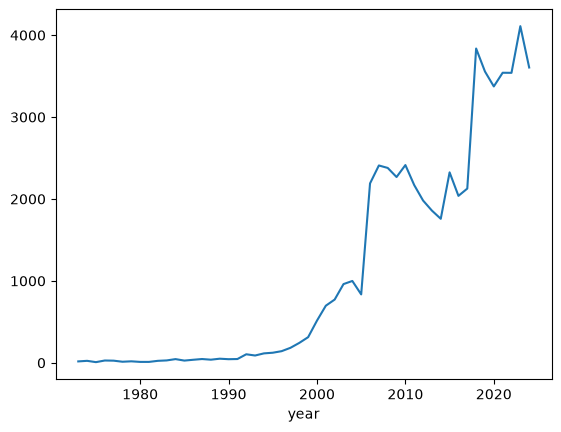

In [30]:
press.groupby("year").size().plot()